<a href="https://colab.research.google.com/github/mollybocock/AI-Assignment-1/blob/main/Semantic_Mirrors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setting up Libraries and retrieving API Key, tests if API key works

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mollybocock/blob/main/Semantic_Mirrors.ipynb)

The project: The goal of this project is to examine oppositeness in sentences and map them onto the embedding space to provide insight into how humans and LLMs understand opposites, and how this compares to vectorized opposites in the embedding space. LLMs are generally algined with humans when aksing for the opposite of short, simple setnece i.e. "I love bananas" to "I hate bananas." For longer sentences, the LLM asked if I wished the opposite sentence to be opposite in feeling or by providing antonyms to individual words. The LLM was they less successful identifying opposites by cultural reference. What the "opposite" of something is v.s. what is the greatest distance away are two separate ideas that made it challenging to come up with an unbiased question not designed to trick human participants of a survey or an LLM. LLMs understand capitalized letters and lower case letters differently, whereas this is unlikely a consideration for humans. 26 human survey responses were generated and respondants were asked to provide an opposite word for each word in the sentence "The quick brown fox jumps over the lazy dog." This sentence is simple enough for everyone to understand, uses all of the letters in the Enlgish alphabet, but is not so short so as to not generate interesting results. Furthermore, by asking for the opposite words a "mirror" sentence could be constructed as well as word-level analysis. The human generated responses, the LLM (from chat GPT) generated response, and the original sentence were vectorized using OpenAI's API and then mapped using t-SNE and UMAP. This pipeline was put into a streamlit app for user interaction and usability.

Findings: The opposite sentence that was the farthest from the prompt was generated by a human. The scatter of human opposites show that an "opposite" is subjective and context dependent, and this is even with a couple of words from the survey that were mostly the same across responses (dog---cat, quick---slow). It appers that the LLM is giving a general approximation of what an opposite is, and is therefore providing an opposite in the semantic conext of what it believes is a human perspective. The LLM is finding a significant vetor distance from the original prompt, but not givig the actual opposite according to its embedding space. It appears the LLM want the sentences to be distinct, but not too far off of what a human might say. A limitation her is that the promt asked for words specifically in order to keep uniformity among human generated and LLM generated data, but that is limiting to an LLM who might have "###" as the opposite of a word in its embedding space.  Adding more requirements to the prompt, such as asking recipients to provide a mixture of antonyms, conceptual differences, and spelling errors or unusual word choices could yield more distinct results but arguably less organic. Overall, humans display a more nuanced concept of opposites while LLMs could likely provide more dramatic results but appear to adopt a common ground approach to try and align with thier understanding of human understanding better.

In [ ]:
# In a Colab cell:

!pip install --upgrade openai pandas matplotlib seaborn scikit-learn umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 87.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
# In the first code cell after restarting:

from openai import OpenAI          # ← new v1+ entrypoint
from google.colab import userdata  # to fetch your stored key

# 1) Instantiate the client with your key
client = OpenAI(api_key=userdata.get("Secret-Key"))

# 2) Test a chat completion
try:
    resp = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role":"user","content":"Hello!"}],
        max_tokens=5
    )
    print("✅ Chat OK:", resp.choices[0].message.content.strip())
except Exception as e:
    print("❌ Chat failed:", e)

# 3) Test an embedding
try:
    emb = client.embeddings.create(
        model="text-embedding-3-small",
        input="Test embedding"
    ).data[0].embedding
    print("✅ Embedding length:", len(emb))
except Exception as e:
    print("❌ Embedding failed:", e)
#Source:https://chatgpt.com/share/6803fe0c-cf44-8005-9ee9-7356011ef188

✅ Chat OK: Hello! How can I
✅ Embedding length: 1536


#Uploading CSV file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving human_survey_responses.csv to human_survey_responses.csv


In [ ]:
import pandas as pd
# Read the uploaded CSV file
survey_df = pd.read_csv('human_survey_responses.csv')
# Display the first few rows to verify the content
survey_df.head()

,Timestamp,The,Quick,Brown,Fox,Jumps,Over,The.1,Lazy,Dog
0,4/12/2025 10:21:31,A,Slow,Red,Dog,Crawl,Under,A,Hard working,Cat
1,4/12/2025 12:00:34,An,Slow,Green,Dog,Stands,Under,An,Not lazy,Cat
2,4/12/2025 12:00:41,Start,Slow,Red,Hound,Sits,Under,Start,Active,Cat
3,4/12/2025 12:09:01,A,Slow,White,Sloth,Sleeps,Under,A,Energetic,Cat
4,4/12/2025 12:15:22,A,Slow,Black,Rabbit,Walks,Under,An,Quick,Cat


#Preprocessing and Adressing Capitol Letters

The first time I ran code to define the LLM opposites from Chat GPT I noticed that "the" only appeared once. From here I learned that python dictionaries can't have duplicate keys, so if a dictionary is defined with the same key twice only the last value is kept. I also learned that Python dictionaries are case sensitive. OpenAI's embeddings are also very case sensitive source: https://community.openai.com/t/is-openai-chatgpt-tokenization-case-sensitive/231108/2. This represents a challenge/limitation becuase humans generating oppsoite words do not have the same case sensitivity. Furthermore, OpenAI's embeddings are also punctuation sensitive source: https://community.openai.com/t/embedding-very-sensitive-to-punctuation/546205 I removed the punction, the period "." from the original sentence to feed the LLM and to give to the human survey response to reduce bias, because asking for the opposite of an input is not the same as aksing what is the farthest away from this input. Asking a human "what is the greatest distance from each of these inputs" is too confusing, but asking an an LLM "what is the oppsite of this input" and "what is the farthest distance away from this input" generates two different answers. I did not want to try and trick the LLM in my prompt, becuase asking an LLM to generate an opposite vs to generate what is the farthest distance away in the embedding space is very different.

In [ ]:
def preprocess_for_embedding(text):
    words = text.split()
    if not words:
        return ""
    # Keep first word capitalization, lowercase the rest
    return words[0] + " " + " ".join(word.lower() for word in words[1:])

# Define the opposites with proper capitalization
llm_opposites = {
    "The": "A",      # Capitalized as it appears at start of sentence
    "quick": "slow",
    "brown": "white",
    "fox": "dog",
    "jumps": "falls",
    "over": "under",
    "the": "a",      # Lowercase as it appears mid-sentence
    "lazy": "energetic",
    "dog": "cat"
}

# Display the opposites
print("Semantic mirror opposites:")
for word, opposite in llm_opposites.items():
    print(f"{word} → {opposite}")

Semantic mirror opposites:
The → A
quick → slow
brown → white
fox → dog
jumps → falls
over → under
the → a
lazy → energetic
dog → cat


#Creating a script that given the Original Sentence will spit out all opposite sentences as well as a script for embeddings

In [ ]:
# Importing the necessary modules
import sys
import importlib

# Add the scripts directory to Python's path
sys.path.append('/content/sample_data/scripts')

# Now import the module
import opposites_generator

# Reload the module to reflect any changes
importlib.reload(opposites_generator)

# Now you can import specific functions
from opposites_generator import generate_all_opposite_sentences, generate_llm_sentence, get_most_common_opposites

# Your code can continue here

✅ Chat OK: Hello there! How can
✅ Embedding length: 1536
Running embedding analysis with tsne...
Step 1: Creating sentences dataframe...
Created DataFrame with 29 sentences
- 1 original sentence
- 2 LLM-generated sentences (regular and capitalization-aware)
- 26 human-generated sentences

Step 2: Generating embeddings...
Generating embeddings...
[1/29] Getting embedding for: The quick brown fox jumps over the lazy ...
[2/29] Getting embedding for: A slow white dog falls under a energetic...
[3/29] Getting embedding for: A slow white dog falls under a energetic...
[4/29] Getting embedding for: A slow red dog crawl under a hard workin...
[5/29] Getting embedding for: An slow green dog stands under an not la...
[6/29] Getting embedding for: Start slow red hound sits under start ac...
[7/29] Getting embedding for: A slow white sloth sleeps under a energe...
[8/29] Getting embedding for: A slow black rabbit walks under an quick...
[9/29] Getting embedding for: Of slow black bird rolls under

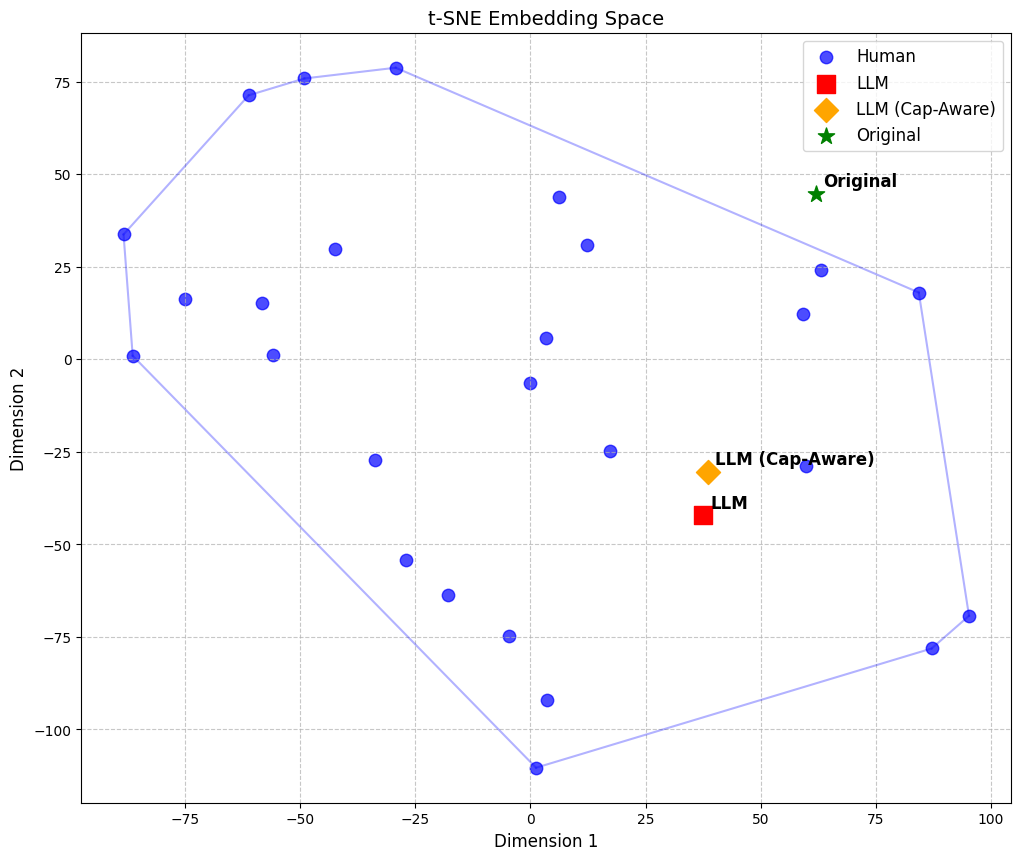

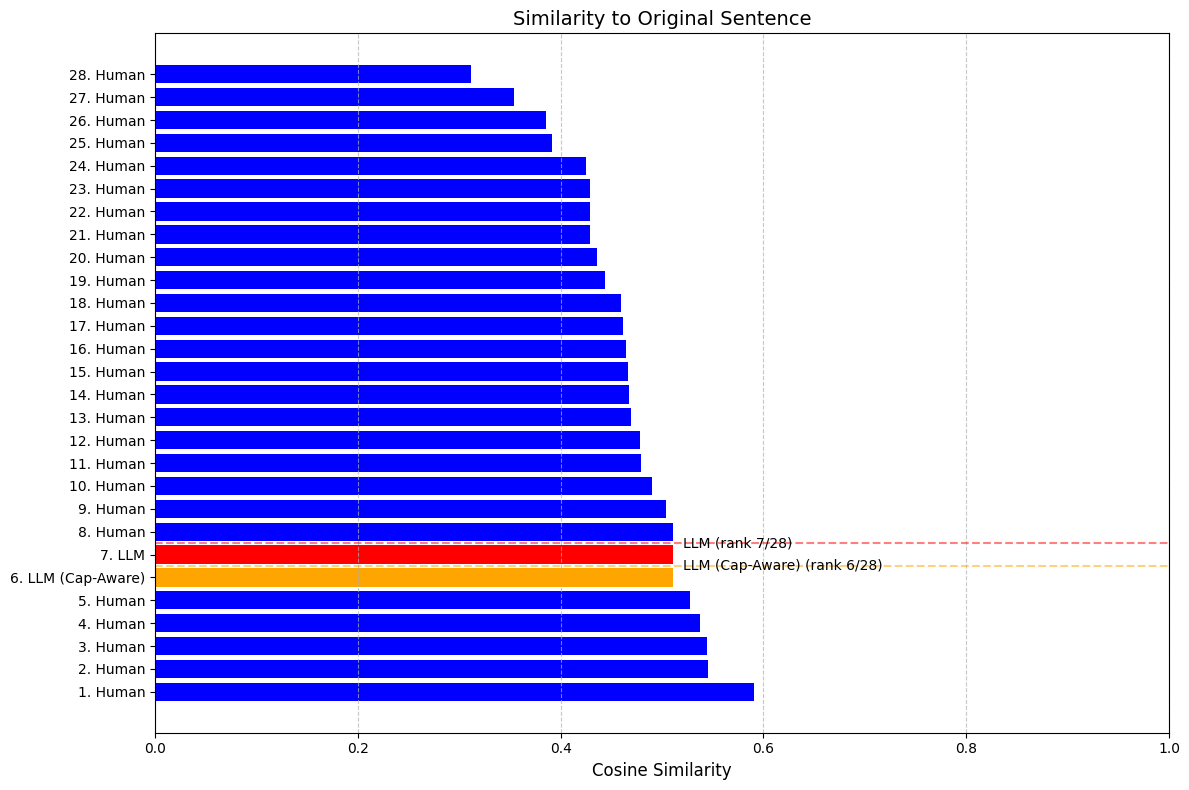

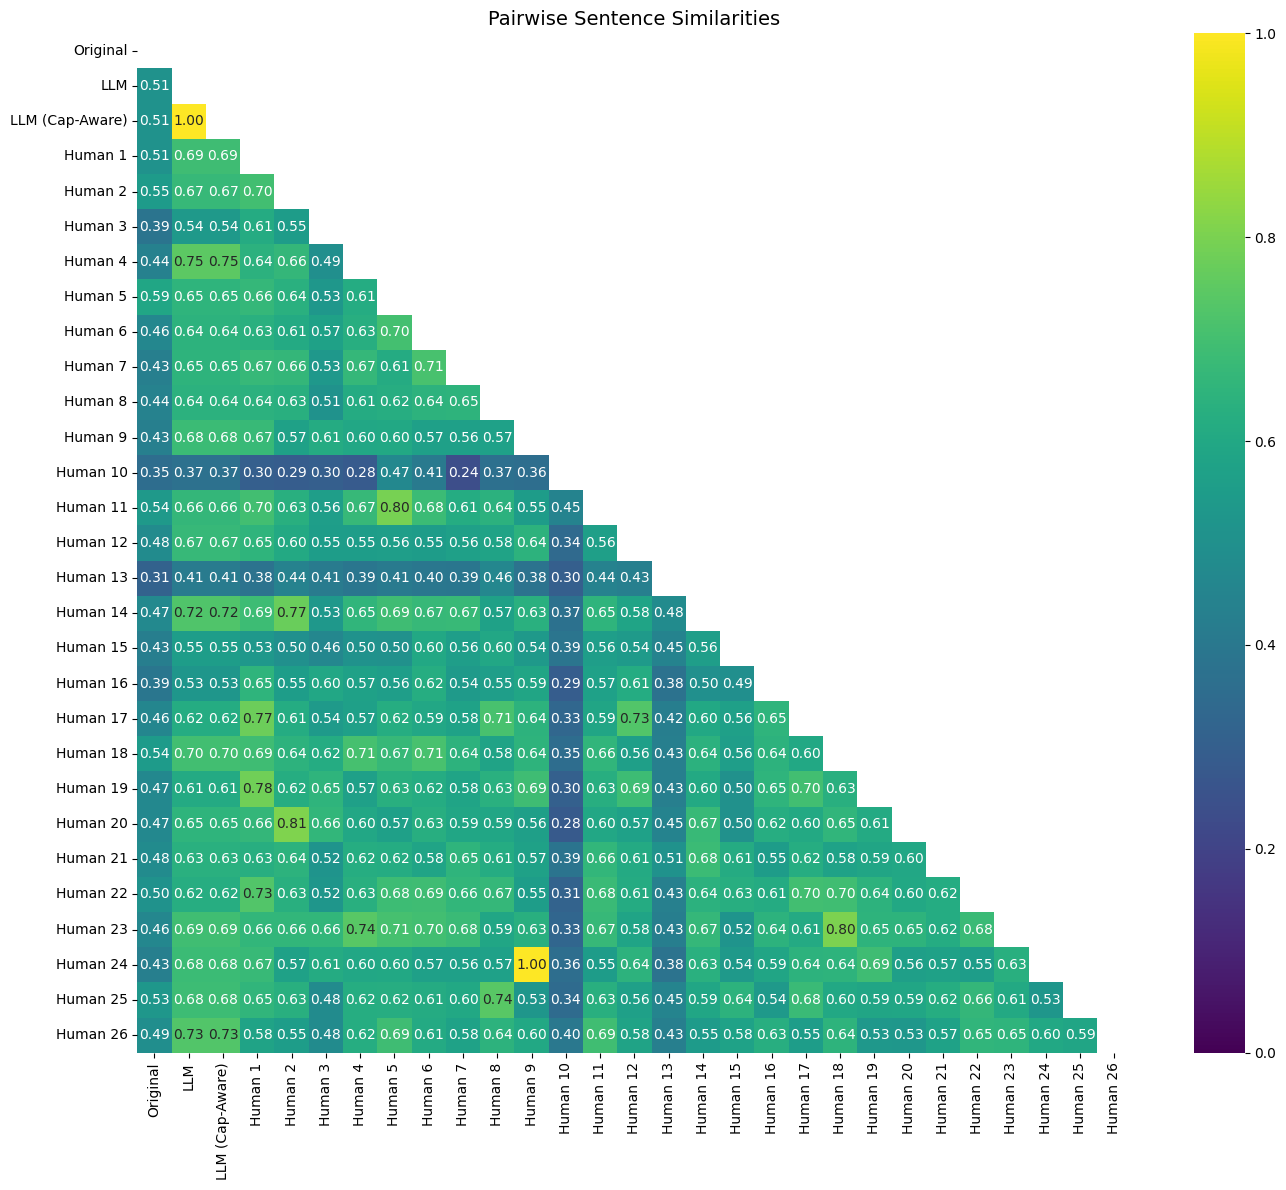

In [ ]:
import sys
sys.path.append('/content/sample_data/scripts')
import simplified_embedding_analysis as sea
import opposites_generator as og

# Now you can use both modules
df = sea.run_embedding_analysis()

In [ ]:
import sys
import importlib
import importlib.util
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Function to dynamically import modules from specific paths
def import_module_from_path(module_name, module_path=None):
    """Import a module from a specific path or from sys.path if path not provided."""
    if module_name in sys.modules:
        return importlib.reload(sys.modules[module_name])

    if module_path and os.path.exists(module_path):
        spec = importlib.util.spec_from_file_location(module_name, module_path)
        module = importlib.util.module_from_spec(spec)
        sys.modules[module_name] = module
        spec.loader.exec_module(module)
        return module

    return importlib.import_module(module_name)

# Define file paths - update these to your actual paths
sea_path = '/content/sample_data/scripts/simplified_embedding_analysis.py'
og_path = '/content/sample_data/scripts/opposites_generator.py'

# Add the scripts directory to Python's path
scripts_dir = '/content/sample_data/scripts'
if scripts_dir not in sys.path:
    sys.path.append(scripts_dir)

# Import the modules
sea = import_module_from_path('simplified_embedding_analysis', sea_path)

# Define a function for enhanced 2D t-SNE visualization
def create_enhanced_2d_tsne(data, labels=None, perplexity=30, n_iter=1000, seed=42):
    """
    Create an enhanced 2D t-SNE visualization with improved aesthetics.

    Parameters:
    - data: DataFrame or array containing the features
    - labels: Optional categorical labels for coloring points
    - perplexity: t-SNE perplexity parameter
    - n_iter: Number of iterations for t-SNE
    - seed: Random seed for reproducibility

    Returns:
    - fig, ax: The figure and axis objects
    """
    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=seed)
    tsne_result = tsne.fit_transform(scaled_data)

    # Create a stylish figure
    plt.style.use('seaborn-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 10))

    # Prepare for coloring
    if labels is not None:
        # Use a nice color palette
        palette = sns.color_palette("viridis", len(np.unique(labels)))
        colors = [palette[i] for i in labels]

        # Create scatter plot with labels
        scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                  c=labels, cmap='viridis',
                  alpha=0.8, s=80, edgecolors='w', linewidth=0.5)

        # Add a color bar
        legend = ax.legend(*scatter.legend_elements(),
                          loc="upper right", title="Clusters")
        ax.add_artist(legend)
    else:
        # If no labels, use a gradient coloring based on the first t-SNE component
        scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                  c=tsne_result[:, 0], cmap='plasma',
                  alpha=0.8, s=80, edgecolors='w', linewidth=0.5)
        plt.colorbar(scatter, ax=ax, label='t-SNE component 1 value')

    # Improve the aesthetics
    ax.set_title('t-SNE Visualization', fontsize=20, pad=20)
    ax.set_xlabel('t-SNE Feature 1', fontsize=14)
    ax.set_ylabel('t-SNE Feature 2', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)

    # Add a subtle background color
    ax.set_facecolor('#f8f9fa')
    fig.set_facecolor('white')

    plt.tight_layout()
    return fig, ax

# Define a function for enhanced 3D t-SNE visualization
def create_enhanced_3d_tsne(data, labels=None, perplexity=30, n_iter=1000, seed=42):
    """
    Create an enhanced 3D t-SNE visualization with improved aesthetics.

    Parameters:
    - data: DataFrame or array containing the features
    - labels: Optional categorical labels for coloring points
    - perplexity: t-SNE perplexity parameter
    - n_iter: Number of iterations for t-SNE
    - seed: Random seed for reproducibility

    Returns:
    - fig, ax: The figure and axis objects
    """
    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Apply t-SNE with 3 components
    tsne = TSNE(n_components=3, perplexity=perplexity, n_iter=n_iter, random_state=seed)
    tsne_result = tsne.fit_transform(scaled_data)

    # Create a stylish 3D figure
    plt.style.use('seaborn-whitegrid')
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')

    # Prepare for coloring
    if labels is not None:
        # Use a nice color palette
        palette = sns.color_palette("viridis", len(np.unique(labels)))
        colors = [palette[i] for i in labels]

        # Create scatter plot with labels
        scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2],
                  c=labels, cmap='viridis',
                  alpha=0.8, s=60, edgecolors='w', linewidth=0.5)

        # Add a color bar
        cbar = fig.colorbar(ScalarMappable(cmap='viridis'), ax=ax)
        cbar.set_label('Cluster', fontsize=14)
    else:
        # If no labels, use a gradient coloring
        scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2],
                  c=tsne_result[:, 2], cmap='plasma',
                  alpha=0.8, s=60, edgecolors='w', linewidth=0.5)
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label('t-SNE component 3 value', fontsize=14)

    # Improve the aesthetics
    ax.set_title('3D t-SNE Visualization', fontsize=20, pad=20)
    ax.set_xlabel('t-SNE Feature 1', fontsize=14)
    ax.set_ylabel('t-SNE Feature 2', fontsize=14)
    ax.set_zlabel('t-SNE Feature 3', fontsize=14)

    # Set the camera angle for better visualization
    ax.view_init(30, 45)

    # Add grid lines for better depth perception
    ax.xaxis._axinfo['grid']['linestyle'] = '--'
    ax.yaxis._axinfo['grid']['linestyle'] = '--'
    ax.zaxis._axinfo['grid']['linestyle'] = '--'

    # Slight transparency for the panes
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.95))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.95))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.95))

    plt.tight_layout()
    return fig, ax

# Example usage (assuming you have a dataframe 'df' with your data):
#
# # For 2D visualization:
# fig_2d, ax_2d = create_enhanced_2d_tsne(df.drop('target', axis=1), labels=df['target'])
# plt.show()
#
# # For 3D visualization:
# fig_3d, ax_3d = create_enhanced_3d_tsne(df.drop('target', axis=1), labels=df['target'])
# plt.show()

# Using the simplified_embedding_analysis module:
#
# # Run the embedding analysis
# df = sea.run_embedding_analysis()
#
# # Assuming the module returns a dataframe with embeddings and possibly labels
# # For unlabeled data:
# fig_2d, ax_2d = create_enhanced_2d_tsne(df)
# plt.show()
#
# # For labeled data (assuming 'label' column exists):
# if 'label' in df.columns:
#     fig_2d, ax_2d = create_enhanced_2d_tsne(df.drop('label', axis=1), labels=df['label'])
#     plt.show()
#
# # For 3D visualization:
# fig_3d, ax_3d = create_enhanced_3d_tsne(df)
# plt.show()

✅ Chat OK: Hello! How can I
✅ Embedding length: 1536


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Add the scripts directory to Python's path
import sys
import os

# Add the scripts directory to Python's path
scripts_dir = '/content/sample_data/scripts'
if scripts_dir not in sys.path:
    sys.path.append(scripts_dir)

# Try to import the modules
try:
    import opposites_generator as opposite_words
    print("Successfully imported opposites_generator")
except ImportError as e:
    print(f"Error importing opposites_generator: {e}")

try:
    import simplified_embedding_analysis as sea
    print("Successfully imported simplified_embedding_analysis")
except ImportError as e:
    print(f"Error importing simplified_embedding_analysis: {e}")

# Check if the files exist
print(f"opposites_generator.py exists: {os.path.exists('/content/sample_data/scripts/opposites_generator.py')}")
print(f"simplified_embedding_analysis.py exists: {os.path.exists('/content/sample_data/scripts/simplified_embedding_analysis.py')}")

# If the modules import successfully, we can continue with visualization

Successfully imported opposites_generator
Successfully imported simplified_embedding_analysis
opposites_generator.py exists: True
simplified_embedding_analysis.py exists: True


In [ ]:
# Create the embedding_viz.py file that we need
with open('embedding_viz.py', 'w') as f:
    f.write("""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import pickle
import os

# Function to load sentence embeddings from pickle file
def load_embeddings(file_path):
    with open(file_path, 'rb') as f:
        embeddings = pickle.load(f)
    return embeddings

# Function to prepare embedding data for visualization
def prepare_embedding_data(embeddings):
    # Check the type of embeddings
    if isinstance(embeddings, dict):
        # Handle dictionary format
        if 'embeddings' in embeddings:
            embedding_array = np.array(embeddings['embeddings'])
            sentences = embeddings.get('sentences', None)
            labels = embeddings.get('labels', None)
        else:
            # Assume keys are sentences and values are embeddings
            sentences = list(embeddings.keys())
            embedding_array = np.array(list(embeddings.values()))
            labels = None
    elif isinstance(embeddings, pd.DataFrame):
        # Handle DataFrame format
        if 'embedding' in embeddings.columns:
            embedding_array = np.stack(embeddings['embedding'].values)
            sentences = embeddings['sentence'].values if 'sentence' in embeddings.columns else None
            labels = embeddings['label'].values if 'label' in embeddings.columns else None
        else:
            # Assume all numeric columns are the embedding
            numeric_cols = embeddings.select_dtypes(include=[np.number]).columns
            embedding_array = embeddings[numeric_cols].values
            non_numeric_cols = embeddings.select_dtypes(exclude=[np.number]).columns
            sentences = embeddings[non_numeric_cols[0]].values if len(non_numeric_cols) > 0 else None
            labels = None
    else:
        # Assume it's already a numpy array
        embedding_array = np.array(embeddings)
        sentences = None
        labels = None

    return embedding_array, sentences, labels

# Create artistic t-SNE visualization for embeddings
def visualize_embeddings_tsne(embeddings, n_components=2, perplexity=None, n_iter=3000,
                             gradient_style='rainbow', point_size=100, background_color='black',
                             edge_color='white', alpha=0.8, show_labels=False, seed=42,
                             save_path=None):
    # Prepare the data
    embedding_array, sentences, labels = prepare_embedding_data(embeddings)

    # Calculate appropriate perplexity if not provided
    if perplexity is None:
        # Set perplexity to min(30, n_samples-1) to avoid the error
        perplexity = min(30, embedding_array.shape[0] - 1)
        print(f"Setting perplexity to {perplexity} (based on {embedding_array.shape[0]} samples)")
    else:
        # Make sure perplexity is valid
        if perplexity >= embedding_array.shape[0]:
            perplexity = embedding_array.shape[0] - 1
            print(f"Adjusted perplexity to {perplexity} (based on {embedding_array.shape[0]} samples)")

    # Apply t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity,
                n_iter=n_iter, random_state=seed)
    tsne_result = tsne.fit_transform(embedding_array)

    # Create a custom colormap if needed
    if gradient_style == 'custom':
        # Create a custom colormap transitioning from purple to pink
        colors = [(0.4, 0, 0.8), (0.8, 0, 0.6), (1, 0, 0.4)]  # Purple to pink
        custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)
        cmap = custom_cmap
    else:
        cmap = gradient_style

    # Create the plot
    plt.style.use('dark_background' if background_color == 'black' else 'default')

    if n_components == 2:
        # 2D Plot
        fig, ax = plt.subplots(figsize=(14, 12), facecolor=background_color)

        if labels is not None:
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=labels, cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add legend if there are labels
            legend = ax.legend(*scatter.legend_elements(),
                              loc="upper right", title="Categories")
            legend.get_title().set_fontsize('14')
            for text in legend.get_texts():
                text.set_fontsize('12')
        else:
            # If no labels, use the first t-SNE component for coloring
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=tsne_result[:, 0], cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add a colorbar
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('t-SNE Component 1', fontsize=14,
                          color='white' if background_color == 'black' else 'black')
            cbar.ax.tick_params(colors='white' if background_color == 'black' else 'black')

        # Add sentence labels if requested
        if show_labels and sentences is not None:
            for i, txt in enumerate(sentences):
                # Truncate the text if it's too long
                display_txt = txt[:20] + '...' if len(txt) > 20 else txt
                ax.annotate(display_txt, (tsne_result[i, 0], tsne_result[i, 1]),
                           fontsize=8, color='white' if background_color == 'black' else 'black')

        # Style the plot
        ax.set_title('Sentence Embeddings Visualization', fontsize=24,
                    color='white' if background_color == 'black' else 'black', pad=20)
        ax.set_xlabel('t-SNE Feature 1', fontsize=16,
                     color='white' if background_color == 'black' else 'black')
        ax.set_ylabel('t-SNE Feature 2', fontsize=16,
                     color='white' if background_color == 'black' else 'black')

        # Remove the grid for a cleaner look
        ax.grid(False)

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Set background color
        ax.set_facecolor(background_color)

    else:
        # 3D Plot
        fig = plt.figure(figsize=(16, 14), facecolor=background_color)
        ax = fig.add_subplot(111, projection='3d')

        if labels is not None:
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2],
                      c=labels, cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add a colorbar
            cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
            cbar.set_label('Category', fontsize=16,
                          color='white' if background_color == 'black' else 'black')
            cbar.ax.tick_params(colors='white' if background_color == 'black' else 'black')
        else:
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2],
                      c=tsne_result[:, 2], cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add a colorbar
            cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
            cbar.set_label('t-SNE Component 3', fontsize=16,
                          color='white' if background_color == 'black' else 'black')
            cbar.ax.tick_params(colors='white' if background_color == 'black' else 'black')

        # Add sentence labels if requested (only for a few points to avoid clutter)
        if show_labels and sentences is not None:
            # Only label a subset of points to avoid overcrowding
            n_labels = min(10, len(sentences))
            step = max(1, len(sentences) // n_labels)
            for i in range(0, len(sentences), step):
                # Truncate the text if it's too long
                display_txt = sentences[i][:15] + '...' if len(sentences[i]) > 15 else sentences[i]
                ax.text(tsne_result[i, 0], tsne_result[i, 1], tsne_result[i, 2], display_txt,
                       fontsize=8, color='white' if background_color == 'black' else 'black')

        # Style the plot
        ax.set_title('3D Sentence Embeddings Visualization', fontsize=24,
                    color='white' if background_color == 'black' else 'black', pad=20)
        ax.set_xlabel('t-SNE Feature 1', fontsize=16,
                     color='white' if background_color == 'black' else 'black')
        ax.set_ylabel('t-SNE Feature 2', fontsize=16,
                     color='white' if background_color == 'black' else 'black')
        ax.set_zlabel('t-SNE Feature 3', fontsize=16,
                     color='white' if background_color == 'black' else 'black')

        # Set view angle
        ax.view_init(30, 45)

        # Set tick colors
        ax.tick_params(colors='white' if background_color == 'black' else 'black')

        # Remove the grid and panes for a cleaner look
        ax.grid(False)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('none')
        ax.yaxis.pane.set_edgecolor('none')
        ax.zaxis.pane.set_edgecolor('none')

    plt.tight_layout()

    # Save the figure if a path is provided
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig, ax
""")

In [ ]:
# Create the embedding_viz.py file
with open('embedding_viz.py', 'w') as f:
    f.write("""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import pickle
import os

# Function to load sentence embeddings from pickle file
def load_embeddings(file_path):
    with open(file_path, 'rb') as f:
        embeddings = pickle.load(f)
    return embeddings

# Function to prepare embedding data for visualization
def prepare_embedding_data(embeddings):
    # Check the type of embeddings
    if isinstance(embeddings, dict):
        # Handle dictionary format
        if 'embeddings' in embeddings:
            embedding_array = np.array(embeddings['embeddings'])
            sentences = embeddings.get('sentences', None)
            labels = embeddings.get('labels', None)
        else:
            # Assume keys are sentences and values are embeddings
            sentences = list(embeddings.keys())
            embedding_array = np.array(list(embeddings.values()))
            labels = None
    elif isinstance(embeddings, pd.DataFrame):
        # Handle DataFrame format
        if 'embedding' in embeddings.columns:
            embedding_array = np.stack(embeddings['embedding'].values)
            sentences = embeddings['sentence'].values if 'sentence' in embeddings.columns else None
            labels = embeddings['label'].values if 'label' in embeddings.columns else None
        else:
            # Assume all numeric columns are the embedding
            numeric_cols = embeddings.select_dtypes(include=[np.number]).columns
            embedding_array = embeddings[numeric_cols].values
            non_numeric_cols = embeddings.select_dtypes(exclude=[np.number]).columns
            sentences = embeddings[non_numeric_cols[0]].values if len(non_numeric_cols) > 0 else None
            labels = None
    else:
        # Assume it's already a numpy array
        embedding_array = np.array(embeddings)
        sentences = None
        labels = None

    return embedding_array, sentences, labels

# Create artistic t-SNE visualization for embeddings
def visualize_embeddings_tsne(embeddings, n_components=2, perplexity=None, n_iter=3000,
                             gradient_style='rainbow', point_size=100, background_color='black',
                             edge_color='white', alpha=0.8, show_labels=False, seed=42,
                             save_path=None):
    # Prepare the data
    embedding_array, sentences, labels = prepare_embedding_data(embeddings)

    # Calculate appropriate perplexity if not provided
    if perplexity is None:
        # Set perplexity to min(30, n_samples-1) to avoid the error
        perplexity = min(30, embedding_array.shape[0] - 1)
        print(f"Setting perplexity to {perplexity} (based on {embedding_array.shape[0]} samples)")
    else:
        # Make sure perplexity is valid
        if perplexity >= embedding_array.shape[0]:
            perplexity = embedding_array.shape[0] - 1
            print(f"Adjusted perplexity to {perplexity} (based on {embedding_array.shape[0]} samples)")

    # Apply t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity,
                n_iter=n_iter, random_state=seed)
    tsne_result = tsne.fit_transform(embedding_array)

    # Create a custom colormap if needed
    if gradient_style == 'custom':
        # Create a custom colormap transitioning from purple to pink
        colors = [(0.4, 0, 0.8), (0.8, 0, 0.6), (1, 0, 0.4)]  # Purple to pink
        custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)
        cmap = custom_cmap
    else:
        cmap = gradient_style

    # Create the plot
    plt.style.use('dark_background' if background_color == 'black' else 'default')

    if n_components == 2:
        # 2D Plot
        fig, ax = plt.subplots(figsize=(14, 12), facecolor=background_color)

        if labels is not None:
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=labels, cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add legend if there are labels
            legend = ax.legend(*scatter.legend_elements(),
                              loc="upper right", title="Categories")
            legend.get_title().set_fontsize('14')
            for text in legend.get_texts():
                text.set_fontsize('12')
        else:
            # If no labels, use the first t-SNE component for coloring
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=tsne_result[:, 0], cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add a colorbar
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('t-SNE Component 1', fontsize=14,
                          color='white' if background_color == 'black' else 'black')
            cbar.ax.tick_params(colors='white' if background_color == 'black' else 'black')

        # Add sentence labels if requested
        if show_labels and sentences is not None:
            for i, txt in enumerate(sentences):
                # Truncate the text if it's too long
                display_txt = txt[:20] + '...' if len(txt) > 20 else txt
                ax.annotate(display_txt, (tsne_result[i, 0], tsne_result[i, 1]),
                           fontsize=8, color='white' if background_color == 'black' else 'black')

        # Style the plot
        ax.set_title('Sentence Embeddings Visualization', fontsize=24,
                    color='white' if background_color == 'black' else 'black', pad=20)
        ax.set_xlabel('t-SNE Feature 1', fontsize=16,
                     color='white' if background_color == 'black' else 'black')
        ax.set_ylabel('t-SNE Feature 2', fontsize=16,
                     color='white' if background_color == 'black' else 'black')

        # Remove the grid for a cleaner look
        ax.grid(False)

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Set background color
        ax.set_facecolor(background_color)

    else:
        # 3D Plot
        fig = plt.figure(figsize=(16, 14), facecolor=background_color)
        ax = fig.add_subplot(111, projection='3d')

        if labels is not None:
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2],
                      c=labels, cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add a colorbar
            cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
            cbar.set_label('Category', fontsize=16,
                          color='white' if background_color == 'black' else 'black')
            cbar.ax.tick_params(colors='white' if background_color == 'black' else 'black')
        else:
            scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2],
                      c=tsne_result[:, 2], cmap=cmap, s=point_size,
                      alpha=alpha, edgecolor=edge_color, linewidth=0.8)

            # Add a colorbar
            cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
            cbar.set_label('t-SNE Component 3', fontsize=16,
                          color='white' if background_color == 'black' else 'black')
            cbar.ax.tick_params(colors='white' if background_color == 'black' else 'black')

        # Add sentence labels if requested (only for a few points to avoid clutter)
        if show_labels and sentences is not None:
            # Only label a subset of points to avoid overcrowding
            n_labels = min(10, len(sentences))
            step = max(1, len(sentences) // n_labels)
            for i in range(0, len(sentences), step):
                # Truncate the text if it's too long
                display_txt = sentences[i][:15] + '...' if len(sentences[i]) > 15 else sentences[i]
                ax.text(tsne_result[i, 0], tsne_result[i, 1], tsne_result[i, 2], display_txt,
                       fontsize=8, color='white' if background_color == 'black' else 'black')

        # Style the plot
        ax.set_title('3D Sentence Embeddings Visualization', fontsize=24,
                    color='white' if background_color == 'black' else 'black', pad=20)
        ax.set_xlabel('t-SNE Feature 1', fontsize=16,
                     color='white' if background_color == 'black' else 'black')
        ax.set_ylabel('t-SNE Feature 2', fontsize=16,
                     color='white' if background_color == 'black' else 'black')
        ax.set_zlabel('t-SNE Feature 3', fontsize=16,
                     color='white' if background_color == 'black' else 'black')

        # Set view angle
        ax.view_init(30, 45)

        # Set tick colors
        ax.tick_params(colors='white' if background_color == 'black' else 'black')

        # Remove the grid and panes for a cleaner look
        ax.grid(False)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('none')
        ax.yaxis.pane.set_edgecolor('none')
        ax.zaxis.pane.set_edgecolor('none')

    plt.tight_layout()

    # Save the figure if a path is provided
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig, ax
""")

In [ ]:
pip install pandas numpy matplotlib scikit-learn sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 903.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

Loaded 28 sentences from 3 different sources
Added capitalization-aware sentence. New dataframe size: 29


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Created embeddings of shape (29, 384)
Source categories: {'Original': 0, 'LLM': 1, 'Human': 2, 'LLM (Cap-Aware)': 3}


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


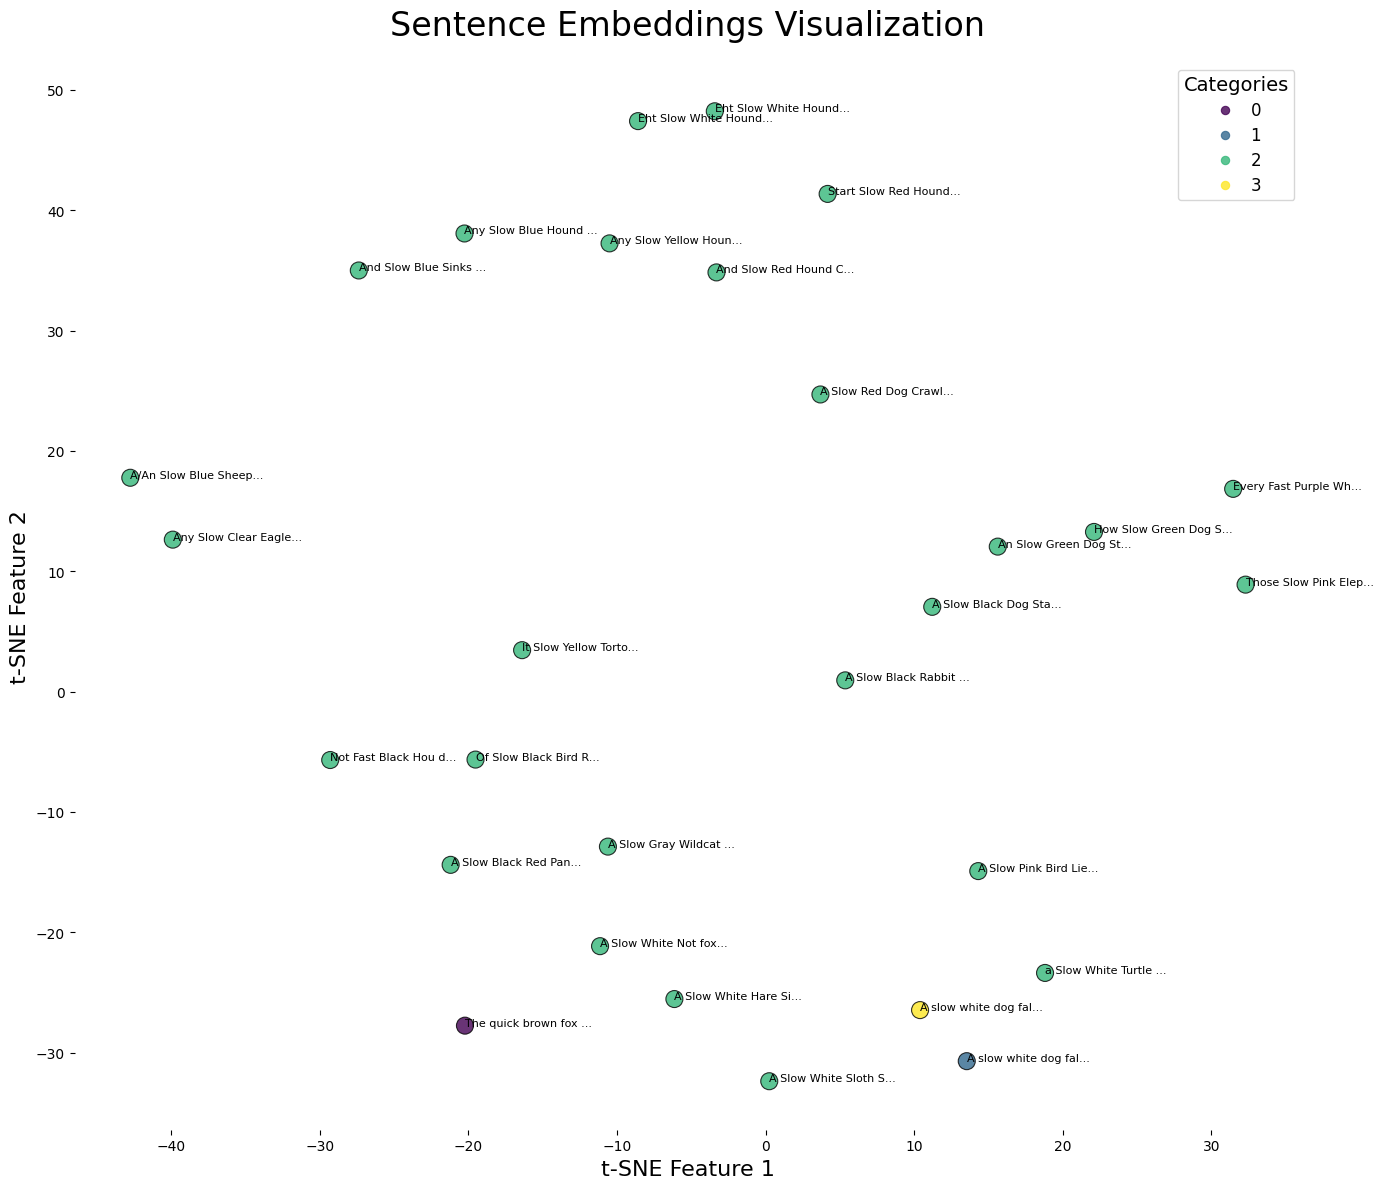

Visualization saved to 'visualizations/embedding_space_rainbow.png'


In [ ]:
# Install the sentence-transformers package if not already installed
!pip install -q sentence-transformers

# Import necessary modules
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# Add the scripts directory to Python's path
scripts_dir = '/content/sample_data/scripts'
if scripts_dir not in sys.path:
    sys.path.append(scripts_dir)

# Import the required modules
import opposites_generator as opposite_words
import embedding_viz

# Create directory for visualizations
os.makedirs('visualizations', exist_ok=True)

# Get data from opposites_generator
df = opposite_words.get_all_data_as_dataframe()
print(f"Loaded {len(df)} sentences from {len(df['source'].unique())} different sources")

# Add capitalization-aware LLM sentence
cap_aware_sentence = opposite_words.generate_capitalization_aware_sentence()
cap_aware_df = pd.DataFrame({
    "source": ["LLM (Cap-Aware)"],
    "timestamp": [""],
    "sentence": [cap_aware_sentence]
})

# Combine all data
df = pd.concat([df, cap_aware_df], ignore_index=True)
print(f"Added capitalization-aware sentence. New dataframe size: {len(df)}")

# Create sentence embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = df['sentence'].tolist()
embeddings = model.encode(sentences)
print(f"Created embeddings of shape {embeddings.shape}")

# Create a mapping from source categories to numeric values
source_categories = {source: i for i, source in enumerate(df['source'].unique())}
print(f"Source categories: {source_categories}")
numeric_labels = np.array([source_categories[source] for source in df['source']])

# Create a dictionary with all the required data
embedding_data = {
    'embeddings': embeddings,
    'sentences': sentences,
    'labels': numeric_labels
}

# Create and save the visualization
fig, ax = embedding_viz.visualize_embeddings_tsne(
    embedding_data,
    perplexity=5,  # Smaller value for smaller datasets
    gradient_style='viridis',  # Use a colormap that works well with categoricals
    point_size=150,  # Larger points for better visibility
    show_labels=True,  # Show labels for key points
    background_color='white',  # Use white background
    edge_color='black',  # Black edges for contrast
    save_path='visualizations/embedding_space_rainbow.png'
)

# Show the plot
plt.show()

print("Visualization saved to 'visualizations/embedding_space_rainbow.png'")
#Source:https://colab.research.google.com/drive/1FfKzFlXGUYSbTJ_-Pr4TrCL79i-3RApO#scrollTo=UwqsBSMXvGUc&line=1&uniqifier=1

#3D Plotting

In [ ]:
# Install required packages
!pip install -q sentence-transformers matplotlib numpy pandas scikit-learn plotly

# Import necessary modules
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import plotly.express as px
!pip install -U kaleido

# Import your opposites generator module
# Make sure the path is correct for your environment
import opposites_generator as opposite_words

# Create directory for visualizations
os.makedirs('visualizations', exist_ok=True)

# Get data from opposites_generator
df = opposite_words.get_all_data_as_dataframe()
print(f"Loaded {len(df)} sentences from {len(df['source'].unique())} different sources")

# Add capitalization-aware LLM sentence
cap_aware_sentence = opposite_words.generate_capitalization_aware_sentence()
cap_aware_df = pd.DataFrame({
    "source": ["LLM (Cap-Aware)"],
    "timestamp": [""],
    "sentence": [cap_aware_sentence]
})

# Add the consensus sentence
consensus_sentence = opposite_words.get_consensus_opposite_sentence()
consensus_df = pd.DataFrame({
    "source": ["Consensus"],
    "timestamp": [""],
    "sentence": [consensus_sentence]
})

# Calculate distances between sentences in the embedding space
# Find the most distant sentence from the LLM opposite
print("\nAnalyzing distances in embedding space:")

# Find the indices of original and LLM sentences
original_idx = df[df['source'] == 'Original'].index[0]
llm_idx = df[df['source'] == 'LLM'].index[0]

# Calculate Euclidean distances in the original embedding space
# (not the t-SNE space, as original distances are more meaningful)
from scipy.spatial.distance import pdist, squareform

# Calculate pairwise distances between all embeddings
distances = squareform(pdist(embeddings, 'euclidean'))

# Get distance from original to LLM opposite
original_to_llm_distance = distances[original_idx, llm_idx]
print(f"Distance from original to LLM opposite: {original_to_llm_distance:.4f}")

# Find the sentence farthest from the LLM opposite
farthest_from_llm_idx = np.argmax(distances[llm_idx])
farthest_from_llm_sentence = df.loc[farthest_from_llm_idx, 'sentence']
farthest_from_llm_source = df.loc[farthest_from_llm_idx, 'source']
farthest_distance = distances[llm_idx, farthest_from_llm_idx]

print(f"Sentence farthest from LLM opposite: {farthest_from_llm_sentence}")
print(f"Source: {farthest_from_llm_source}")
print(f"Distance: {farthest_distance:.4f}")

# Also find sentence most semantically opposite to the original
farthest_from_original_idx = np.argmax(distances[original_idx])
farthest_from_original_sentence = df.loc[farthest_from_original_idx, 'sentence']
farthest_from_original_source = df.loc[farthest_from_original_idx, 'source']
farthest_from_original_distance = distances[original_idx, farthest_from_original_idx]

print(f"\nSentence farthest from original: {farthest_from_original_sentence}")
print(f"Source: {farthest_from_original_source}")
print(f"Distance: {farthest_from_original_distance:.4f}")

# Add the farthest sentence information to the dataframe
farthest_from_llm_df = pd.DataFrame({
    "source": ["Farthest from LLM"],
    "timestamp": [""],
    "sentence": [farthest_from_llm_sentence]
})
# After calculating distances and before creating embeddings, define your color and legend mappings:

# Create a color mapping for different sources
color_mapping = {
    'Original': '#1f77b4',  # Blue
    'LLM': '#ff7f0e',       # Orange
    'Human': '#2ca02c',     # Green
    'LLM (Cap-Aware)': '#d62728',  # Red
    'Consensus': '#9467bd',  # Purple
}

# Create a better legend mapping
legend_mapping = {
    'Original': 'Original Sentence',
    'LLM': 'LLM Generated Opposite',
    'Human': 'Human Generated Opposite',
    'LLM (Cap-Aware)': 'LLM (Capitalization-Aware)',
    'Consensus': 'Consensus Opposite',
}

# Then use them in your farthest_from_llm section
if farthest_from_llm_idx != original_idx:  # Don't add if it's the original sentence
    df = pd.concat([df, farthest_from_llm_df], ignore_index=True)
    color_mapping["Farthest from LLM"] = '#17becf'  # Cyan
    legend_mapping["Farthest from LLM"] = "Farthest from LLM Opposite"
    print("Added 'Farthest from LLM' sentence to visualization")

# Continue with your model creation and embedding
model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = df['sentence'].tolist()
embeddings = model.encode(sentences)
# Only add it if it's not already in the dataset
if farthest_from_llm_idx != original_idx:  # Don't add if it's the original sentence
    df = pd.concat([df, farthest_from_llm_df], ignore_index=True)
    color_mapping["Farthest from LLM"] = '#17becf'  # Cyan
    legend_mapping["Farthest from LLM"] = "Farthest from LLM Opposite"
    print("Added 'Farthest from LLM' sentence to visualization")
model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = df['sentence'].tolist()
embeddings = model.encode(sentences)
print(f"Created embeddings of shape {embeddings.shape}")

# Use t-SNE to reduce to 3 dimensions
print("Performing t-SNE dimensionality reduction to 3D...")
tsne = TSNE(n_components=3, perplexity=5, random_state=42, n_iter=1000)
embeddings_3d = tsne.fit_transform(embeddings)

# Create a color mapping for different sources
color_mapping = {
    'Original': '#1f77b4',  # Blue
    'LLM': '#ff7f0e',       # Orange
    'Human': '#2ca02c',     # Green
    'LLM (Cap-Aware)': '#d62728',  # Red
    'Consensus': '#9467bd',  # Purple
    'Farthest from LLM': '#17becf'  # Cyan - Add this immediately
}

# Create a better legend mapping
legend_mapping = {
    'Original': 'Original Sentence',
    'LLM': 'LLM Generated Opposite',
    'Human': 'Human Generated Opposite',
    'LLM (Cap-Aware)': 'LLM (Capitalization-Aware)',
    'Consensus': 'Consensus Opposite',
    'Farthest from LLM': 'Farthest from LLM Opposite'  # Add this immediately
}

# Prepare data for plotly
colors = [color_mapping[source] for source in df['source']]
labels = [legend_mapping.get(source, source) for source in df['source']]

# Create a dataframe for plotly
plot_df = pd.DataFrame({
    'x': embeddings_3d[:, 0],
    'y': embeddings_3d[:, 1],
    'z': embeddings_3d[:, 2],
    'sentence': sentences,
    'source': df['source'],
    'label': labels,
    'color': colors
})

# Create a 3D scatter plot with plotly
fig = px.scatter_3d(
    plot_df,
    x='x', y='y', z='z',
    color='source',
    color_discrete_map=color_mapping,
    hover_data=['sentence'],
    labels={'source': 'Source Type'},
    title='3D t-SNE Visualization of Sentence Embeddings',
    opacity=0.8,
    size_max=10
)

# Add connecting lines between original sentence and opposite sentences
# First, find the coordinates of the original sentence
original_idx = plot_df[plot_df['source'] == 'Original'].index[0]
original_coords = [
    plot_df.loc[original_idx, 'x'],
    plot_df.loc[original_idx, 'y'],
    plot_df.loc[original_idx, 'z']
]

# Add lines connecting original to each human response
for idx in plot_df[plot_df['source'] == 'Human'].index:
    human_coords = [plot_df.loc[idx, 'x'], plot_df.loc[idx, 'y'], plot_df.loc[idx, 'z']]

    # Create a line trace
    line_trace = go.Scatter3d(
        x=[original_coords[0], human_coords[0]],
        y=[original_coords[1], human_coords[1]],
        z=[original_coords[2], human_coords[2]],
        mode='lines',
        line=dict(color='rgba(44, 160, 44, 0.3)', width=2),  # Semi-transparent green
        showlegend=False
    )
    fig.add_trace(line_trace)

# Add line connecting original to LLM response (standard)
llm_idx = plot_df[plot_df['source'] == 'LLM'].index[0]
llm_coords = [plot_df.loc[llm_idx, 'x'], plot_df.loc[llm_idx, 'y'], plot_df.loc[llm_idx, 'z']]
fig.add_trace(go.Scatter3d(
    x=[original_coords[0], llm_coords[0]],
    y=[original_coords[1], llm_coords[1]],
    z=[original_coords[2], llm_coords[2]],
    mode='lines',
    line=dict(color='rgba(255, 127, 14, 0.6)', width=3),  # Semi-transparent orange
    showlegend=False
))

# Add line connecting original to LLM Cap-Aware response
if 'LLM (Cap-Aware)' in plot_df['source'].values:
    llm_cap_idx = plot_df[plot_df['source'] == 'LLM (Cap-Aware)'].index[0]
    llm_cap_coords = [plot_df.loc[llm_cap_idx, 'x'], plot_df.loc[llm_cap_idx, 'y'], plot_df.loc[llm_cap_idx, 'z']]
    fig.add_trace(go.Scatter3d(
        x=[original_coords[0], llm_cap_coords[0]],
        y=[original_coords[1], llm_cap_coords[1]],
        z=[original_coords[2], llm_cap_coords[2]],
        mode='lines',
        line=dict(color='rgba(214, 39, 40, 0.6)', width=3),  # Semi-transparent red
        showlegend=False
    ))

# Add line connecting LLM to the farthest sentence
farthest_idx = plot_df[plot_df['source'] == 'Farthest from LLM'].index[0] if 'Farthest from LLM' in plot_df['source'].values else -1

if farthest_idx >= 0:
    farthest_coords = [plot_df.loc[farthest_idx, 'x'], plot_df.loc[farthest_idx, 'y'], plot_df.loc[farthest_idx, 'z']]

    # Add a dashed line connecting LLM to farthest sentence
    fig.add_trace(go.Scatter3d(
        x=[llm_coords[0], farthest_coords[0]],
        y=[llm_coords[1], farthest_coords[1]],
        z=[llm_coords[2], farthest_coords[2]],
        mode='lines',
        line=dict(color='rgba(23, 190, 207, 0.8)', width=4, dash='dash'),  # Dashed cyan line
        name='Maximum Distance from LLM',
        showlegend=True
    ))

# Update marker sizes based on source
for i, trace in enumerate(fig.data):
    source_name = trace.name
    if source_name == 'Original' or source_name == 'LLM' or source_name == 'LLM (Cap-Aware)' or source_name == 'Consensus':
        trace.marker.size = 15  # Larger markers for special points
    else:
        trace.marker.size = 8   # Smaller markers for human responses

# Customize the layout
fig.update_layout(
    scene=dict(
        xaxis=dict(title='t-SNE Dimension 1'),
        yaxis=dict(title='t-SNE Dimension 2'),
        zaxis=dict(title='t-SNE Dimension 3'),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
    ),
    legend_title_text='Sentence Source',
    width=900,
    height=700,
    margin=dict(r=20, l=10, b=10, t=40),
    template="plotly_white"
)

# Show the figure
fig.show()

# Save as HTML for interactive viewing
fig.write_html('visualizations/3d_embeddings_interactive.html')
print("Interactive visualization saved to 'visualizations/3d_embeddings_interactive.html'")

# Create a static image version
fig.write_image('visualizations/3d_embeddings_static.png', scale=2)
print("Static visualization saved to 'visualizations/3d_embeddings_static.png'")

# Additionally, let's create an animated version that rotates around
def create_rotating_animation():
    frames = []
    for angle in range(0, 360, 5):
        camera = dict(
            eye=dict(
                x=1.5 * np.cos(np.radians(angle)),
                y=1.5 * np.sin(np.radians(angle)),
                z=0.8
            )
        )
        frames.append(go.Frame(layout=dict(scene_camera=camera)))

    fig_animated = go.Figure(
        data=fig.data,
        layout=fig.layout,
        frames=frames
    )

    # Add animation settings
    fig_animated.update_layout(
        updatemenus=[{
            'type': 'buttons',
            'showactive': False,
            'buttons': [{
                'label': 'Play',
                'method': 'animate',
                'args': [None, {
                    'frame': {'duration': 30, 'redraw': True},
                    'fromcurrent': True,
                    'transition': {'duration': 0}
                }]
            }]
        }]
    )

    return fig_animated

# Create and save the animated version
fig_animated = create_rotating_animation()
fig_animated.write_html('visualizations/3d_embeddings_animated.html')
print("Animated visualization saved to 'visualizations/3d_embeddings_animated.html'")

# Also create a version with a dark background for better contrast of the lines
fig_dark = go.Figure(data=fig.data)
fig_dark.update_layout(
    scene=dict(
        xaxis=dict(title='t-SNE Dimension 1', backgroundcolor='rgb(20, 20, 40)'),
        yaxis=dict(title='t-SNE Dimension 2', backgroundcolor='rgb(20, 20, 40)'),
        zaxis=dict(title='t-SNE Dimension 3', backgroundcolor='rgb(20, 20, 40)'),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
        bgcolor='rgb(20, 20, 40)'
    ),
    legend_title_text='Sentence Source',
    width=900,
    height=700,
    margin=dict(r=20, l=10, b=10, t=40),
    template="plotly_dark",
    paper_bgcolor='rgb(30, 30, 50)'
)
fig_dark.write_html('visualizations/3d_embeddings_dark.html')
print("Dark-themed visualization saved to 'visualizations/3d_embeddings_dark.html'")

print("Visualization process complete!")

# Optional: Additional analysis of the clustering
from sklearn.cluster import KMeans

# Perform K-means clustering on the embeddings
n_clusters = 4  # You can adjust this
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# Add cluster information to the dataframe
plot_df['cluster'] = clusters

# Print analysis of clusters
print("\nCluster Analysis:")
for cluster in range(n_clusters):
    cluster_sentences = plot_df[plot_df['cluster'] == cluster]['sentence'].tolist()
    cluster_sources = plot_df[plot_df['cluster'] == cluster]['source'].value_counts().to_dict()

    print(f"\nCluster {cluster+1} ({len(cluster_sentences)} sentences):")
    print(f"  Sources: {cluster_sources}")
    print(f"  Sample sentences:")
    for i, sentence in enumerate(cluster_sentences[:3]):  # Print first 3 examples
        print(f"    {i+1}. {sentence}")
        #Source: https://claude.site/artifacts/fe54a0d7-0fd8-4920-983a-cbc385e0a897

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 6.2 MB/s eta 0:00:00
Loaded 28 sentences from 3 different sources

Analyzing distances in embedding space:
Distance from original to LLM opposite: 1.0809
Sentence farthest from LLM opposite: Not Fast Black Hou d Leaps Under Price Animated Car
Source: Human
Distance: 1.2240

Sentence farthest from original: And Slow Blue Sinks Under And Spry Cat
Source: Human
Distance: 1.1867
Added 'Farthest from LLM' sentence to visualization
Added 'Farthest from LLM' sentence to visualization
Created embeddings of shape (30, 384)
Performing t-SNE dimensionality reduction to 3D...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Interactive visualization saved to 'visualizations/3d_embeddings_interactive.html'


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


#Bringing in Streamlit

In [ ]:
# Run this in a Colab cell to set up and launch the Streamlit app

# Step 1: Install required packages
!pip install -q streamlit pandas numpy plotly scikit-learn scipy pyngrok openai umap-learn matplotlib seaborn

# Step 2: Create necessary directories
!mkdir -p /content/visualizations
!mkdir -p /content/data

# Step 3: Create a script to fix module paths and launch Streamlit
with open("/content/launch_streamlit.py", "w") as f:
    f.write("""
import os
import sys
import time
import subprocess
from pyngrok import ngrok, conf

# Configure ngrok
conf.get_default().ngrok_version = "v3"

def kill_existing_processes():
    print("Killing any existing Streamlit or ngrok processes...")
    os.system("pkill -f streamlit || true")
    os.system("pkill -f ngrok || true")
    print("Done!")

def fix_module_paths():
    print("Setting up Python path...")

    # Add scripts directory to Python path
    script_dir = "/content/sample_data/scripts"
    if script_dir not in sys.path:
        sys.path.append(script_dir)
        print(f"Added {script_dir} to Python path")

    # Create symlink for embedding_viz.py if needed
    if os.path.exists("/content/embedding_viz.py"):
        if not os.path.exists("/content/simplified_embedding_analysis.py"):
            print("Creating symlink from embedding_viz.py to simplified_embedding_analysis.py")
            os.symlink("/content/embedding_viz.py", "/content/simplified_embedding_analysis.py")

    return True

def test_imports():
    print("Testing module imports...")

    # Test opposites_generator
    try:
        sys.path.append("/content/sample_data/scripts")
        import opposites_generator
        print("✅ opposites_generator module can be imported")

        try:
            result = opposites_generator.get_all_data_as_dataframe()
            print("✅ opposites_generator.get_all_data_as_dataframe() works!")
            print(f"DataFrame has {len(result)} rows")
        except AttributeError as e:
            print(f"❌ Error calling get_all_data_as_dataframe: {e}")
            print("Check that the function is defined correctly in opposites_generator.py")
            return False
    except ImportError as e:
        print(f"❌ Cannot import opposites_generator: {e}")
        return False

    return True

def create_start_script():
    # Create a startup script to set environment variables
    with open("/content/run_streamlit.sh", "w") as f:
        f.write('''#!/bin/bash
export PYTHONPATH=$PYTHONPATH:/content/sample_data/scripts
cd /content
streamlit run /content/sample_data/scripts/app.py --server.port=8501 --server.headless=true
''')

    # Make it executable
    os.chmod("/content/run_streamlit.sh", 0o755)
    print("Created Streamlit startup script")

def run_streamlit_with_ngrok():
    PORT = 8501

    # Find and remove the existing ngrok binary if exists
    ngrok_path = conf.get_default().ngrok_path
    if os.path.exists(ngrok_path):
        print(f"Removing existing ngrok binary at {ngrok_path}")
        os.remove(ngrok_path)

    # Get the ngrok auth token
    try:
        from google.colab import userdata
        auth_token = userdata.get('NGROK_AUTH_TOKEN')
        print("Got token from Colab secrets")
    except:
        auth_token = input("Enter your ngrok auth token: ")

    # Set the auth token
    ngrok.set_auth_token(auth_token)

    # Create the startup script
    create_start_script()

    # Start Streamlit in the background
    print("Starting Streamlit...")
    os.system("nohup /content/run_streamlit.sh &")

    # Wait for Streamlit to start
    print("Waiting for Streamlit to start...")
    time.sleep(10)

    # Check if Streamlit is running
    result = subprocess.run(["ps", "aux"], capture_output=True, text=True)
    if "streamlit" not in result.stdout:
        print("ERROR: Failed to start Streamlit")
        return False

    print("Streamlit started successfully!")

    # Create ngrok tunnel
    try:
        public_url = ngrok.connect(PORT, bind_tls=True)
        print("\\n" + "="*50)
        print(f"✅ Streamlit is now running at: {public_url}")
        print("="*50 + "\\n")

        # List all active tunnels
        tunnels = ngrok.get_tunnels()
        if tunnels:
            print("All active tunnels:")
            for tunnel in tunnels:
                print(f"  - {tunnel.public_url}")

        print("\\nPress Ctrl+C to stop the server")
        print("Your Streamlit app should be accessible at the URL above")

        # Keep session alive
        while True:
            time.sleep(1)
    except Exception as e:
        print(f"❌ Error creating ngrok tunnel: {e}")
        return False

def main():
    print("="*50)
    print("Setting up and launching Streamlit app with ngrok")
    print("="*50)

    kill_existing_processes()
    fix_module_paths()

    if not test_imports():
        print("❌ Module imports failed. Please fix the issues before continuing.")
        print("Common solutions:")
        print("1. Make sure opposites_generator.py has a get_all_data_as_dataframe() function")
        print("2. Check file locations and permissions")
        return

    run_streamlit_with_ngrok()

if __name__ == "__main__":
    main()
""")

print("Setup script created successfully!")
print("To launch the Streamlit app with ngrok, run: !python /content/launch_streamlit.py")
#Source: https://claude.site/artifacts/b7b5ed23-e578-45af-a697-e3c907b02e43

Setup script created successfully!
To launch the Streamlit app with ngrok, run: !python /content/launch_streamlit.py


In [ ]:
# Install the latest pyngrok
!pip install --upgrade pyngrok

# Import necessary libraries
from pyngrok import ngrok, conf
import os
import sys
import time
import subprocess
from google.colab import userdata

# Make sure pyngrok is using ngrok v3
conf.get_default().ngrok_version = "v3"

# Find and remove the existing ngrok binary that pyngrok uses
ngrok_path = conf.get_default().ngrok_path
if os.path.exists(ngrok_path):
    print(f"Removing existing ngrok binary at {ngrok_path}")
    os.remove(ngrok_path)
else:
    print(f"No existing ngrok binary found at {ngrok_path}")

# Get the token from Google Colab secrets
try:
    auth_token = userdata.get('NGROK_AUTH_TOKEN')
    print("Got token from Colab secrets")
except:
    auth_token = input("Enter your ngrok auth token: ")

# Set the auth token
ngrok.set_auth_token(auth_token)

# Kill any existing ngrok processes
!pkill -f ngrok || true

# Start Streamlit in the background
print("Starting Streamlit...")
!nohup streamlit run /content/sample_data/scripts/app.py --server.port=8501 &

# Give Streamlit time to start
print("Waiting for Streamlit to start...")
time.sleep(8)

# Make sure Streamlit is running
!ps aux | grep streamlit

# Create ngrok tunnel
try:
    public_url = ngrok.connect(8501)
    print("\n" + "="*50)
    print(f"✅ Streamlit is now running at: {public_url}")
    print("="*50 + "\n")

    # List all active tunnels
    tunnels = ngrok.get_tunnels()
    if tunnels:
        print("All active tunnels:")
        for tunnel in tunnels:
            print(f"  - {tunnel.public_url}")
    else:
        print("No active tunnels found - something went wrong")
except Exception as e:
    print(f"❌ Error creating ngrok tunnel: {e}")
    print("Error details:", str(e))
    #Source: Generated with Claude

Removing existing ngrok binary at /root/.config/ngrok/ngrok
Got token from Colab secrets
^C
Starting Streamlit...
nohup: appending output to 'nohup.out'
Waiting for Streamlit to start...
root       41615 10.2  0.4  73488 64504 ?        S    14:43   0:00 /usr/bin/python3 /usr/local/bin/streamlit run /content/sample_data/scripts/app.py --server.port=8501
root       41651  0.0  0.0   7376  3468 ?        S    14:43   0:00 /bin/bash -c ps aux | grep streamlit
root       41653  0.0  0.0   6484  2312 ?        S    14:43   0:00 grep streamlit



✅ Streamlit is now running at: NgrokTunnel: "https://518f-34-134-36-67.ngrok-free.app" -> "http://localhost:8501"

All active tunnels:
  - https://518f-34-134-36-67.ngrok-free.app
